In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
print(pd.__version__)

3.0.0


In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/GabrielOliv235/imersao_dados/refs/heads/main/pandas_imersao/salaries.csv")
df.head(10)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025.0,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M
1,2025.0,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M
2,2025.0,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M
3,2025.0,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M
4,2025.0,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M
5,2025.0,EN,FT,Data Engineer,80000,USD,80000,US,0,US,M
6,2025.0,SE,FT,Data Scientist,185000,USD,185000,US,0,US,M
7,2025.0,SE,FT,Data Scientist,148000,USD,148000,US,0,US,M
8,2025.0,MI,FT,Data Scientist,135000,USD,135000,CA,0,CA,M
9,2025.0,MI,FT,Data Scientist,108000,USD,108000,CA,0,CA,M


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 133349 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   work_year           133339 non-null  float64
 1   experience_level    133349 non-null  str    
 2   employment_type     133349 non-null  str    
 3   job_title           133349 non-null  str    
 4   salary              133349 non-null  int64  
 5   salary_currency     133349 non-null  str    
 6   salary_in_usd       133349 non-null  int64  
 7   employee_residence  133349 non-null  str    
 8   remote_ratio        133349 non-null  int64  
 9   company_location    133349 non-null  str    
 10  company_size        133349 non-null  str    
dtypes: float64(1), int64(3), str(7)
memory usage: 11.2 MB


In [4]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,133339.000000,1.333490e+05,133349.000000,133349.000000
mean,2024.358770,1.632833e+05,157617.272098,20.905669
std,0.680627,2.173860e+05,74288.363097,40.590044
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.060200e+05,106000.000000,0.000000
50%,2024.000000,1.470000e+05,146206.000000,0.000000
75%,2025.000000,1.990000e+05,198000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


In [5]:
df.shape

(133349, 11)

In [6]:
linhas, colunas = df.shape
print(f'╔{"═"*25}╗\n║ DIMENSÕES DO DATASET    ║\n╠{"═"*25}╣\n║ • Linhas: {linhas:<13} ║\n║ • Colunas: {colunas:<13}║\n╚{"═"*25}╝')

╔═════════════════════════╗
║ DIMENSÕES DO DATASET    ║
╠═════════════════════════╣
║ • Linhas: 133349        ║
║ • Colunas: 11           ║
╚═════════════════════════╝


In [7]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='str')

In [8]:
novos_nomes = {
    'work_year': 'ano',
    'experience_level': 'senioridade',
    'employment_type': 'contrato',
    'job_title': 'cargo',
    'salary': 'salario',
    'salary_currency': 'moeda',
    'salary_in_usd': 'usd',
    'employee_residence': 'residencia',
    'remote_ratio': 'remoto',
    'company_location': 'empresa',
    'company_size': 'tamanho_empresa'
}
df.rename(columns=novos_nomes, inplace=True)

In [9]:
df.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M
1,2025.0,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M
2,2025.0,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M
3,2025.0,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M
4,2025.0,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M


In [10]:
df['senioridade'].value_counts()

senioridade
SE    77241
MI    40465
EN    12443
EX     3200
Name: count, dtype: int64

In [11]:
df['contrato'].value_counts()

contrato
FT    132563
CT       394
PT       376
FL        16
Name: count, dtype: int64

In [12]:
df['remoto'].value_counts()

remoto
0      105312
100     27718
50        319
Name: count, dtype: int64

In [13]:
df['tamanho_empresa'].value_counts()

tamanho_empresa
M    129561
L      3574
S       214
Name: count, dtype: int64

In [14]:
senioridade = {
    'SE': 'senior',
    'MI': 'pleno',
    'EN': 'junior',
    'EX': 'executivo'
}
df['senioridade'] = df['senioridade'].replace(senioridade)

In [15]:
df['senioridade'].value_counts()

senioridade
senior       77241
pleno        40465
junior       12443
executivo     3200
Name: count, dtype: int64

In [16]:
contrato = {
    'FT': 'integral',
    'PT': 'parcial',
    'CT': 'contrato',
    'FL': 'freelancer'
}
df['contrato'] = df['contrato'].replace(contrato)

In [17]:
df['contrato'].value_counts()

contrato
integral      132563
contrato         394
parcial          376
freelancer        16
Name: count, dtype: int64

In [18]:
tamanho_empresa = {
    'L': 'grande',
    'S': 'pequena',
    'M':	'media'
}
df['tamanho_empresa'] = df['tamanho_empresa'].replace(tamanho_empresa)

In [19]:
df['tamanho_empresa'].value_counts()

tamanho_empresa
media      129561
grande       3574
pequena       214
Name: count, dtype: int64

In [20]:
mapa_trabalho = {
    0: 'presencial',
    100: 'remoto',
    50: 'hibrido'
}
df['remoto'] = df['remoto'].replace(mapa_trabalho)

In [21]:
df['remoto'].value_counts()

remoto
presencial    105312
remoto         27718
hibrido          319
Name: count, dtype: int64

In [22]:
df.head(30)

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,media
1,2025.0,senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,media
2,2025.0,pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,media
3,2025.0,pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,media
4,2025.0,junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,media
5,2025.0,junior,integral,Data Engineer,80000,USD,80000,US,presencial,US,media
6,2025.0,senior,integral,Data Scientist,185000,USD,185000,US,presencial,US,media
7,2025.0,senior,integral,Data Scientist,148000,USD,148000,US,presencial,US,media
8,2025.0,pleno,integral,Data Scientist,135000,USD,135000,CA,presencial,CA,media
9,2025.0,pleno,integral,Data Scientist,108000,USD,108000,CA,presencial,CA,media


In [23]:
df.describe(include=["object", "string"])

,senioridade,contrato,cargo,moeda,residencia,remoto,empresa,tamanho_empresa
count,133349,133349,133349,133349,133349,133349,133349,133349
unique,4,4,390,26,102,3,95,3
top,senior,integral,Data Scientist,USD,US,presencial,US,media
freq,77241,132563,17314,126140,119579,105312,119641,129561


In [24]:
df.isnull().sum()

ano                10
senioridade         0
contrato            0
cargo               0
salario             0
moeda               0
usd                 0
residencia          0
remoto              0
empresa             0
tamanho_empresa     0
dtype: int64

In [25]:
df['ano'].unique()

array([2025.,   nan, 2024., 2022., 2023., 2020., 2021.])

In [26]:
df[df.isnull().any(axis=1)]

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
5588,NaN,senior,integral,Product Manager,184500,USD,184500,US,presencial,US,media
59692,NaN,pleno,integral,Engineer,110000,USD,110000,DE,presencial,DE,media
59710,NaN,junior,integral,Data Scientist,208800,USD,208800,US,presencial,US,media
59759,NaN,senior,integral,Software Engineer,135000,USD,135000,US,presencial,US,media
59789,NaN,senior,integral,Engineer,112000,USD,112000,US,presencial,US,media
131000,NaN,senior,integral,Machine Learning Engineer,163800,USD,163800,US,presencial,US,media
131006,NaN,senior,integral,Data Analytics Manager,204500,USD,204500,US,presencial,US,media
133054,NaN,junior,integral,Data Scientist,40000,USD,40000,JP,remoto,MY,grande
133281,NaN,pleno,integral,Machine Learning Engineer,180000,PLN,46597,PL,remoto,PL,grande
133317,NaN,pleno,integral,Data Scientist,130000,USD,130000,US,hibrido,US,grande


In [27]:
df_salarios = pd.DataFrame({
    'nome': ['Ana', 'Bruno', 'Carlos', 'Diana', 'Eduardo'],
    'salario': [4000, np.nan, 3500, np.nan, 5000],
    'formação': ['dados','arquitetura', 'engenharia', 'psicologia','administração']
})
df_salarios.head(5)

,nome,salario,formação
0,Ana,4000.0,dados
1,Bruno,NaN,arquitetura
2,Carlos,3500.0,engenharia
3,Diana,NaN,psicologia
4,Eduardo,5000.0,administração


In [28]:
df_salarios['salarios_media'] = df_salarios['salario'].fillna(df_salarios['salario'].mean().round(2))
df_salarios['salarios_mediana'] = df_salarios['salario'].fillna(df_salarios['salario'].mean().round(2))
df_salarios

,nome,salario,formação,salarios_media,salarios_mediana
0,Ana,4000.0,dados,4000.00,4000.00
1,Bruno,NaN,arquitetura,4166.67,4166.67
2,Carlos,3500.0,engenharia,3500.00,3500.00
3,Diana,NaN,psicologia,4166.67,4166.67
4,Eduardo,5000.0,administração,5000.00,5000.00


In [29]:
df_temperaturas = pd.DataFrame({
    'dia': ['segunda', 'terça', 'quarta', 'quinta', 'sexta'],
    'temperatura': [30, np.nan, np.nan, 28, 27]
})
df_temperaturas['temperatura_preenchida'] = df_temperaturas['temperatura'].ffill()
df_temperaturas.head(5)

,dia,temperatura,temperatura_preenchida
0,segunda,30.0,30.0
1,terça,NaN,30.0
2,quarta,NaN,30.0
3,quinta,28.0,28.0
4,sexta,27.0,27.0


In [30]:
df_cidades = pd.DataFrame({
    'nome': ['Ana', 'Bruno', 'Carlos', 'Diana', 'Eduardo'],
    'cidades': ['são paulo', np.nan, 'curitiba', np.nan, 'belem']
})
df_cidades['cidade_preenchida'] = df_cidades['cidades'].fillna('Não informado')
df_cidades

,nome,cidades,cidade_preenchida
0,Ana,são paulo,são paulo
1,Bruno,NaN,Não informado
2,Carlos,curitiba,curitiba
3,Diana,NaN,Não informado
4,Eduardo,belem,belem


In [31]:
df_limpo = df.dropna()

In [32]:
df_limpo.isnull().sum()

ano                0
senioridade        0
contrato           0
cargo              0
salario            0
moeda              0
usd                0
residencia         0
remoto             0
empresa            0
tamanho_empresa    0
dtype: int64

In [33]:
df_limpo = df_limpo.assign(ano=df_limpo['ano'].astype('int64'))
df_limpo

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025,senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,media
1,2025,senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,media
2,2025,pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,media
3,2025,pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,media
4,2025,junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,media
...,...,...,...,...,...,...,...,...,...,...,...
133344,2020,senior,integral,Data Scientist,412000,USD,412000,US,remoto,US,grande
133345,2021,pleno,integral,Principal Data Scientist,151000,USD,151000,US,remoto,US,grande
133346,2020,junior,integral,Data Scientist,105000,USD,105000,US,remoto,US,pequena
133347,2020,junior,contrato,Business Data Analyst,100000,USD,100000,US,remoto,US,grande


<Axes: title={'center': 'Distribuição de senioridade'}, xlabel='senioridade'>

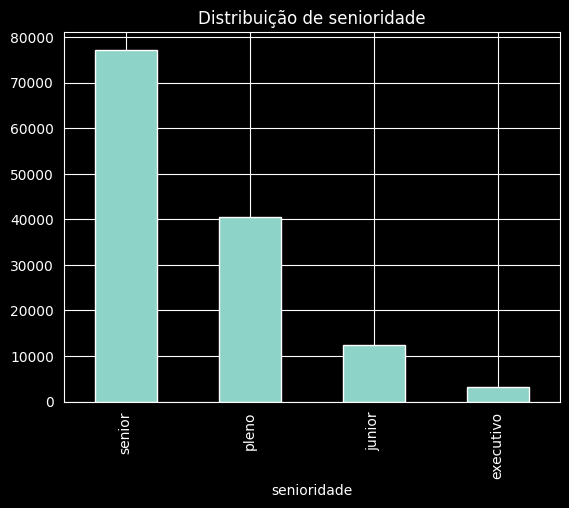

In [34]:
df_limpo['senioridade'].value_counts().plot(kind='bar', title="Distribuição de senioridade")

<Axes: xlabel='senioridade', ylabel='usd'>

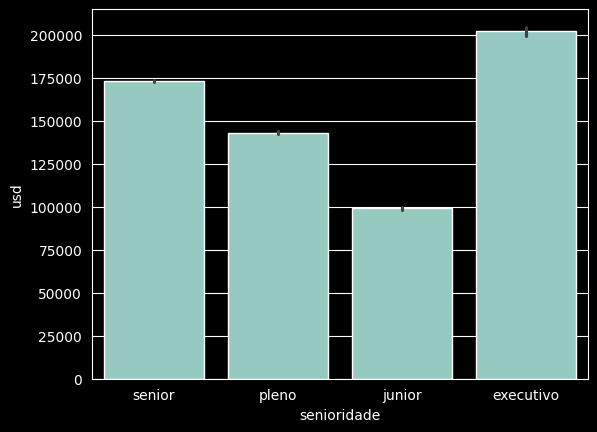

In [35]:
sns.barplot(data=df_limpo, x='senioridade', y='usd')

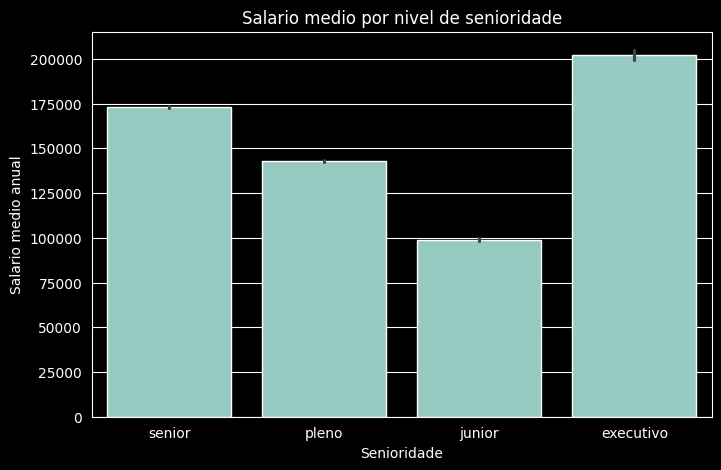

In [36]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_limpo, x='senioridade', y='usd')
plt.title('Salario medio por nivel de senioridade')
plt.xlabel('Senioridade')
plt.ylabel('Salario medio anual')
plt.show()

In [37]:
df_limpo.groupby('senioridade')['usd'].mean().sort_values(ascending=False)

senioridade
executivo    202027.667813
senior       172850.838301
pleno        143044.845979
junior        99034.963267
Name: usd, dtype: float64

In [38]:
ordem = df_limpo.groupby('senioridade')['usd'].mean().sort_values(ascending=False).index

In [39]:
ordem

Index(['executivo', 'senior', 'pleno', 'junior'], dtype='str', name='senioridade')

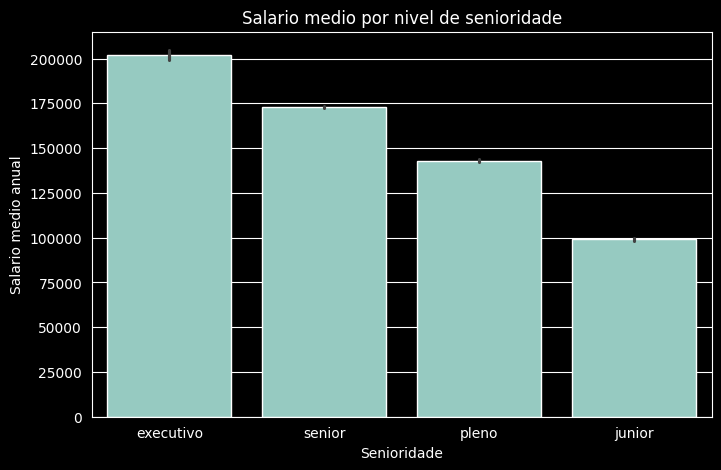

In [40]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_limpo, x='senioridade', y='usd',order = ordem)
plt.title('Salario medio por nivel de senioridade')
plt.xlabel('Senioridade')
plt.ylabel('Salario medio anual')
plt.show()

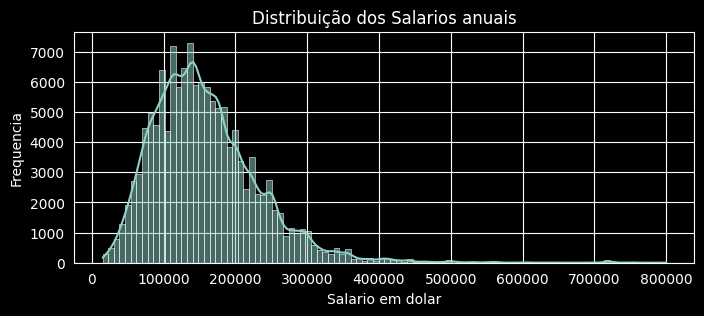

In [41]:
plt.figure(figsize=(8,3))
sns.histplot(df_limpo['usd'], bins = 100, kde=True)
plt.title('Distribuição dos Salarios anuais')
plt.xlabel('Salario em dolar')
plt.ylabel('Frequencia')
plt.show()

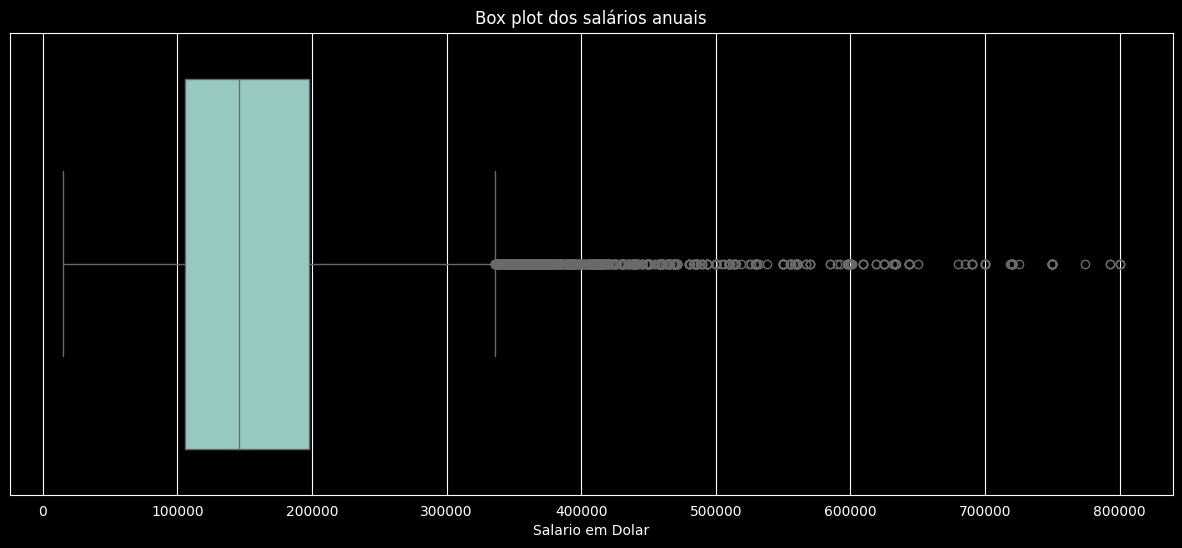

In [42]:
plt.figure(figsize=(15,6))
sns.boxplot(x=df_limpo['usd'])
plt.title('Box plot dos salários anuais')
plt.xlabel('Salario em Dolar')
plt.show()

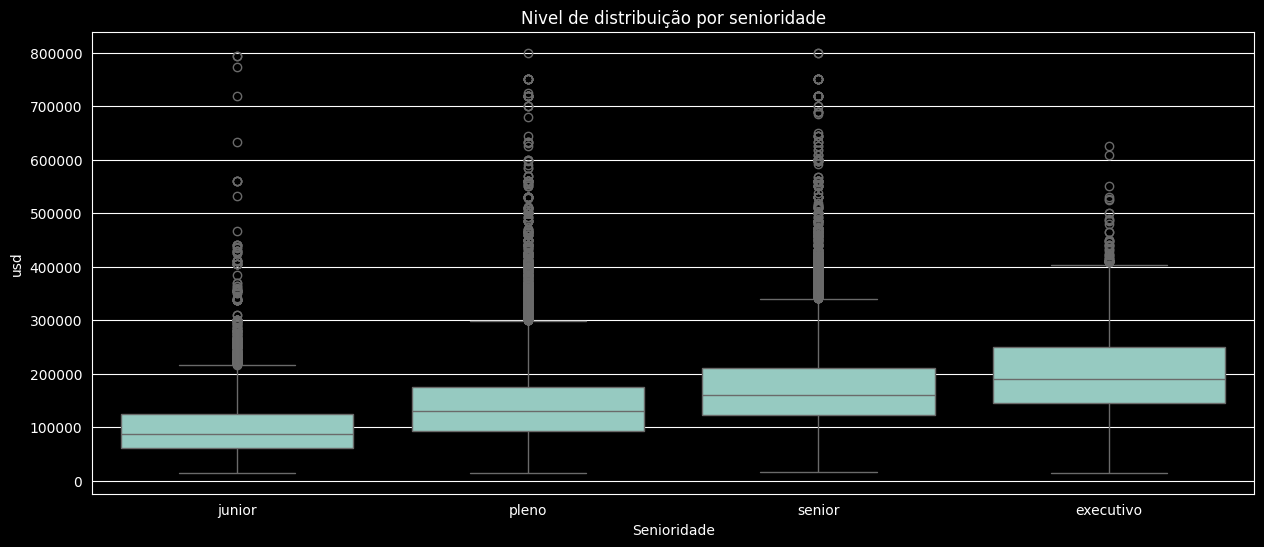

In [43]:
ordem_senioridade = ['junior', 'pleno', 'senior', 'executivo']
plt.figure(figsize=(15,6))
sns.boxplot(x='senioridade', y='usd', data=df_limpo, order=ordem_senioridade)
plt.title('Nivel de distribuição por senioridade')
plt.xlabel('Senioridade')
plt.show()

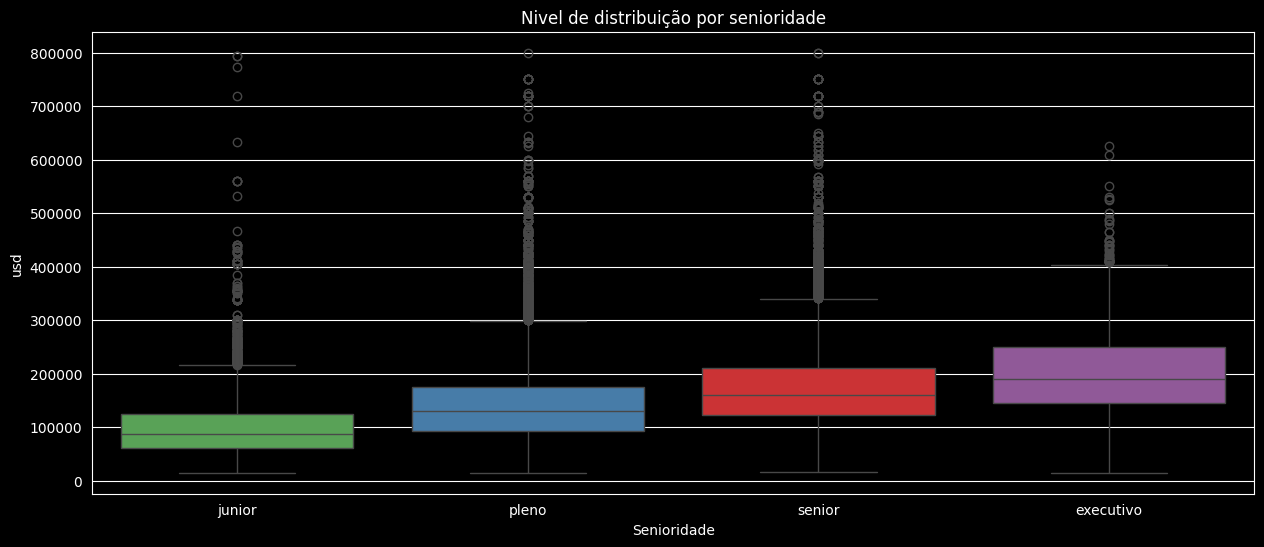

In [44]:
ordem_senioridade = ['junior', 'pleno', 'senior', 'executivo']
plt.figure(figsize=(15,6))
sns.boxplot(x='senioridade', y='usd', data=df_limpo, order=ordem_senioridade, palette='Set1', hue='senioridade')
plt.title('Nivel de distribuição por senioridade')
plt.xlabel('Senioridade')
plt.show()

In [47]:
senioridade_media_salario = df_limpo.groupby('senioridade')['usd'].mean().sort_values(ascending=False).reset_index()
fig = px.bar(senioridade_media_salario,
             x='senioridade',
             y='usd',
             title='Média Salarial por Senioridade',
             labels={'senioridade': 'Nível de Senioridade', 'usd': 'Média Salarial Anual (USD)'}
             )

fig.show()

In [50]:
contagem_remoto = df_limpo['remoto'].value_counts().reset_index()
contagem_remoto.columns = ['tipo_trabalho', 'quantidade']
fig = px.pie(contagem_remoto,
names='tipo_trabalho',
values = 'quantidade',
title='Proporção do tipos de trabalho')
fig.show()

In [54]:
contagem_remoto = df_limpo['remoto'].value_counts().reset_index()
contagem_remoto.columns = ['tipo_trabalho', 'quantidade']
fig = px.pie(contagem_remoto,
names='tipo_trabalho',
values = 'quantidade',
title='Proporção do tipos de trabalho',
hole=0.5)
fig.show()

In [56]:
contagem_remoto = df_limpo['remoto'].value_counts().reset_index()
contagem_remoto.columns = ['tipo_trabalho', 'quantidade']
fig = px.pie(contagem_remoto,
names='tipo_trabalho',
values = 'quantidade',
title='Proporção do tipos de trabalho',
hole=0.5)
fig.update_traces(textinfo='percent+label')
fig.show()